# Wine Quality Exploratory Data Analysis & Modeling

This notebook provides a walkthrough of the **UCI Wine Quality dataset**, analyzing both red and white wine variants. 
We will explore chemical feature distributions, analyze correlations, and train a Random Forest Classifier to distinguish high-quality wines from average ones.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load and Inspect Datasets
Let's load the semicolon-separated dataset files from the `data/` directory.

In [7]:
data_dir = "../data"
red_df = pd.read_csv(os.path.join(data_dir, "winequality-red.csv"), sep=";")
white_df = pd.read_csv(os.path.join(data_dir, "winequality-white.csv"), sep=";")

print(f"Red wine dataset shape: {red_df.shape}")
print(f"White wine dataset shape: {white_df.shape}")

Red wine dataset shape: (1599, 12)
White wine dataset shape: (4898, 12)


In [8]:
# Display first few rows of red wine data
red_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,9.184283,0.398959,0.199259,0.900000,0.083589,49.967025,40.486310,0.995530,3.562397,0.866638,9.089270,6
1,8.079420,0.497079,0.353090,0.900000,0.040389,16.126343,28.418438,0.996042,3.258663,0.556698,11.101539,6
2,9.446978,0.777478,0.305183,3.257501,0.124183,8.024078,20.374592,0.998314,3.685486,0.661921,10.917002,5
3,10.970072,0.413726,0.350835,2.888206,0.037400,35.760538,37.009703,0.993066,3.313672,0.688955,10.035062,6
4,7.912573,0.386145,0.312235,2.155683,0.093366,46.156269,54.531420,1.000077,3.165600,0.550625,10.108275,6


## 2. Visualizing Quality Distributions
The target feature is `quality`, representing sensory scores on a scale from 0 to 10.

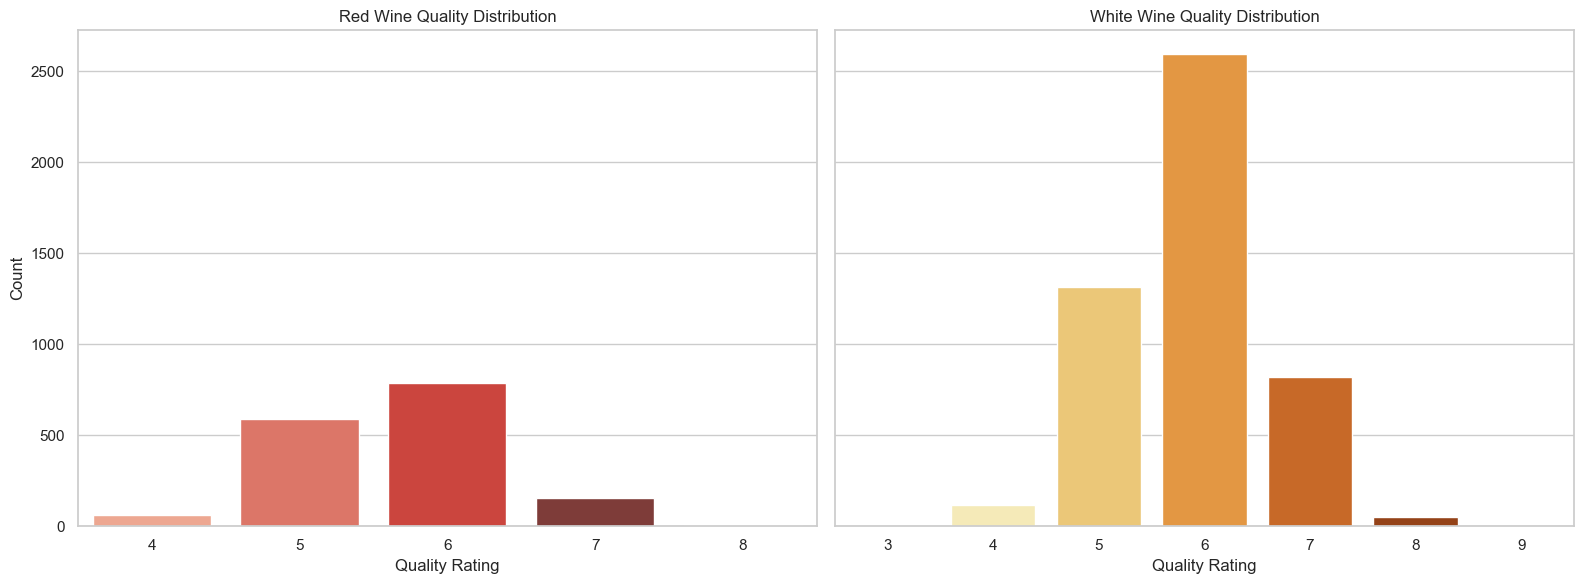

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.countplot(data=red_df, x="quality", hue="quality", ax=axes[0], palette="Reds_d", legend=False)
axes[0].set_title("Red Wine Quality Distribution")
axes[0].set_xlabel("Quality Rating")
axes[0].set_ylabel("Count")

sns.countplot(data=white_df, x="quality", hue="quality", ax=axes[1], palette="YlOrBr", legend=False)
axes[1].set_title("White Wine Quality Distribution")
axes[1].set_xlabel("Quality Rating")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3. Feature Correlation Analysis
Let's look at how chemical features correlate with each other and the target rating.

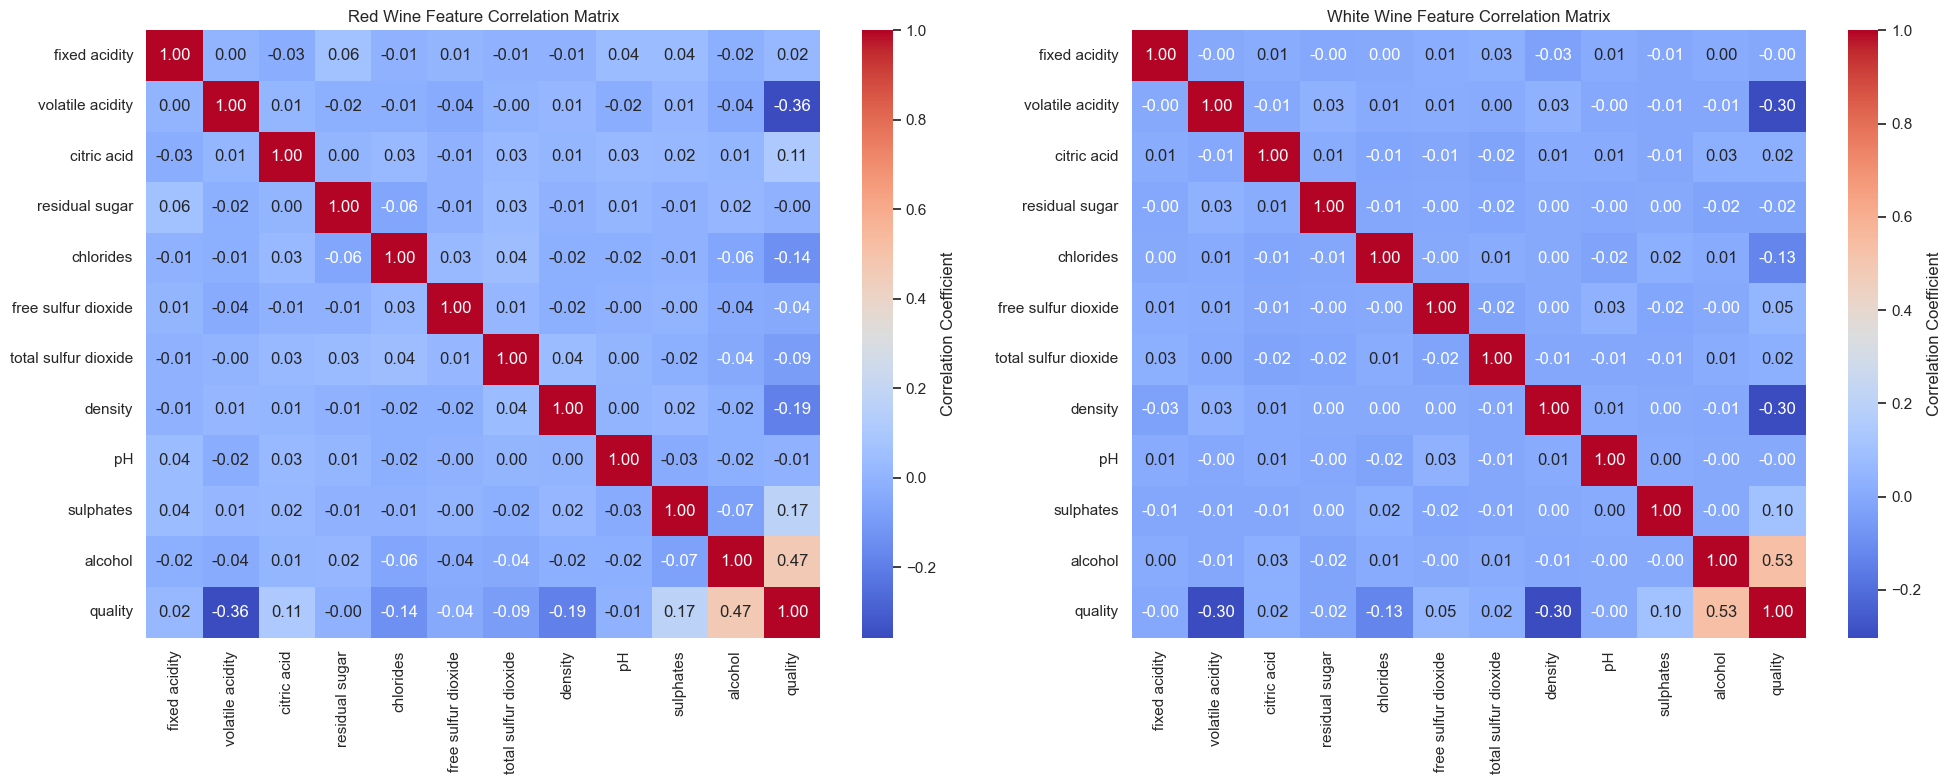

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Red Wine correlation
red_corr = red_df.corr()
sns.heatmap(red_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title("Red Wine Feature Correlation Matrix")

# White Wine correlation
white_corr = white_df.corr()
sns.heatmap(white_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], cbar_kws={'label': 'Correlation Coefficient'})
axes[1].set_title("White Wine Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## 4. Modeling: Random Forest Classification
We frame this as a binary classification task: defining high-quality ("Good") wines as those with a quality rating of **6 or above**.

In [11]:
def train_and_evaluate(df, wine_name):
    print(f"=== Training Random Forest Classifier ({wine_name} Wine) ===\n")
    
    # Preprocess
    X = df.drop(columns=['quality'])
    y = (df['quality'] >= 6).astype(int)  # 1 for Good, 0 for Average
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Fit Model
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Test Partition Accuracy: {accuracy:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Standard (<6)", "Good (>=6)"]))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Standard", "Good"], yticklabels=["Standard", "Good"])
    plt.title(f"Confusion Matrix - {wine_name} Wine")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.show()
    
    # Feature Importance Plot
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': clf.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f"Feature Importance Ranking - {wine_name} Wine")
    plt.tight_layout()
    plt.show()
    
    return clf

=== Training Random Forest Classifier (Red Wine) ===

Test Partition Accuracy: 0.7375

Classification Report:
               precision    recall  f1-score   support

Standard (<6)       0.69      0.63      0.66       130
   Good (>=6)       0.76      0.81      0.79       190

     accuracy                           0.74       320
    macro avg       0.73      0.72      0.72       320
 weighted avg       0.73      0.74      0.74       320



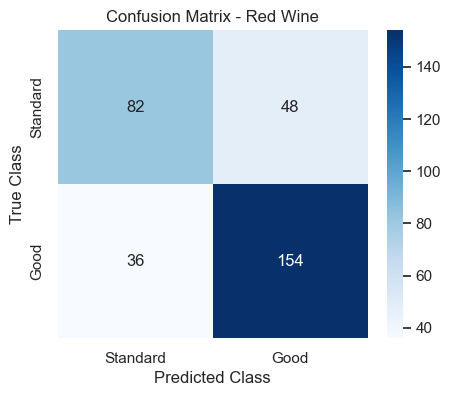

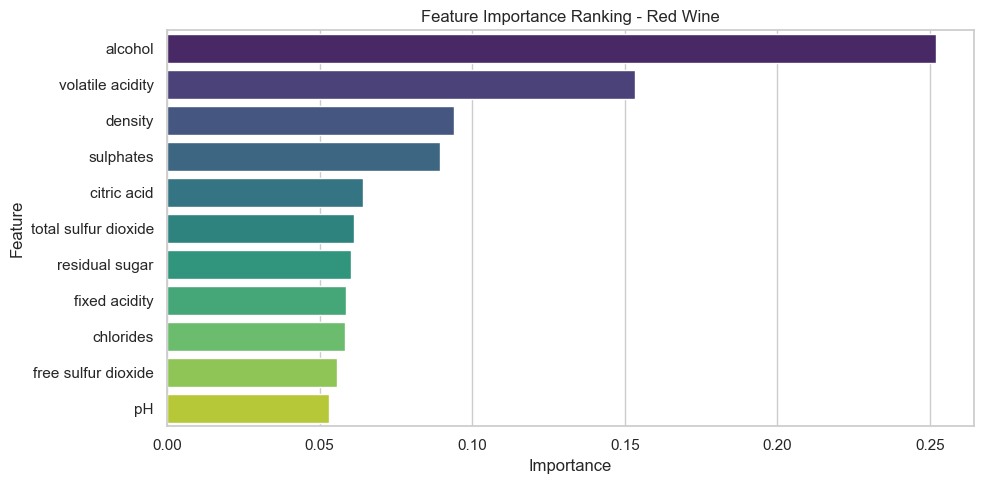

In [12]:
# Run classification pipeline on red wine
red_model = train_and_evaluate(red_df, "Red")

=== Training Random Forest Classifier (White Wine) ===

Test Partition Accuracy: 0.7969

Classification Report:
               precision    recall  f1-score   support

Standard (<6)       0.72      0.50      0.59       287
   Good (>=6)       0.82      0.92      0.86       693

     accuracy                           0.80       980
    macro avg       0.77      0.71      0.73       980
 weighted avg       0.79      0.80      0.78       980



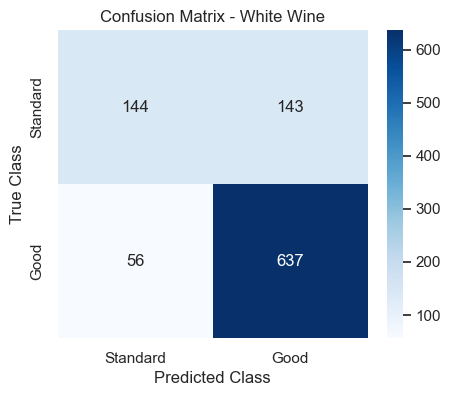

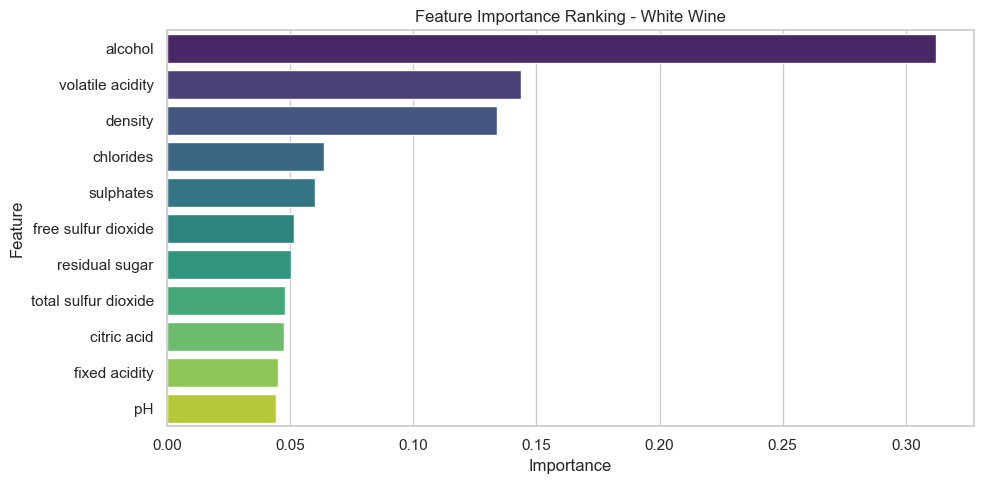

In [13]:
# Run classification pipeline on white wine
white_model = train_and_evaluate(white_df, "White")